<a href="https://colab.research.google.com/github/Novita-data/Unsupervised-learning/blob/main/Unsupervised_casestudy_Novita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
filepath='/content/adult_dataset.csv'
df=pd.read_csv(filepath)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [ ]:
df.isnull().sum()

,0
age,2442
workclass,3362
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,3357
relationship,0
race,0
sex,0


In [ ]:
df.replace('?', np.nan, inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(16)

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,46384.000000,4.882600e+04,48826.000000,48826.000000,48826.000000,46384.000000
mean,38.681528,1.896605e+05,10.078278,1079.421230,87.530988,40.451039
std,13.951072,1.056025e+05,2.570759,7453.214369,403.067466,12.645956
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175550e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781385e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376170e+05,12.000000,0.000000,0.000000,45.000000
max,255.000000,1.490400e+06,16.000000,99999.000000,4356.000000,250.000000


In [ ]:
#splitting numeric and categoric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

cat_cols = df.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country', 'income']


### Histograms for Numerical Columns

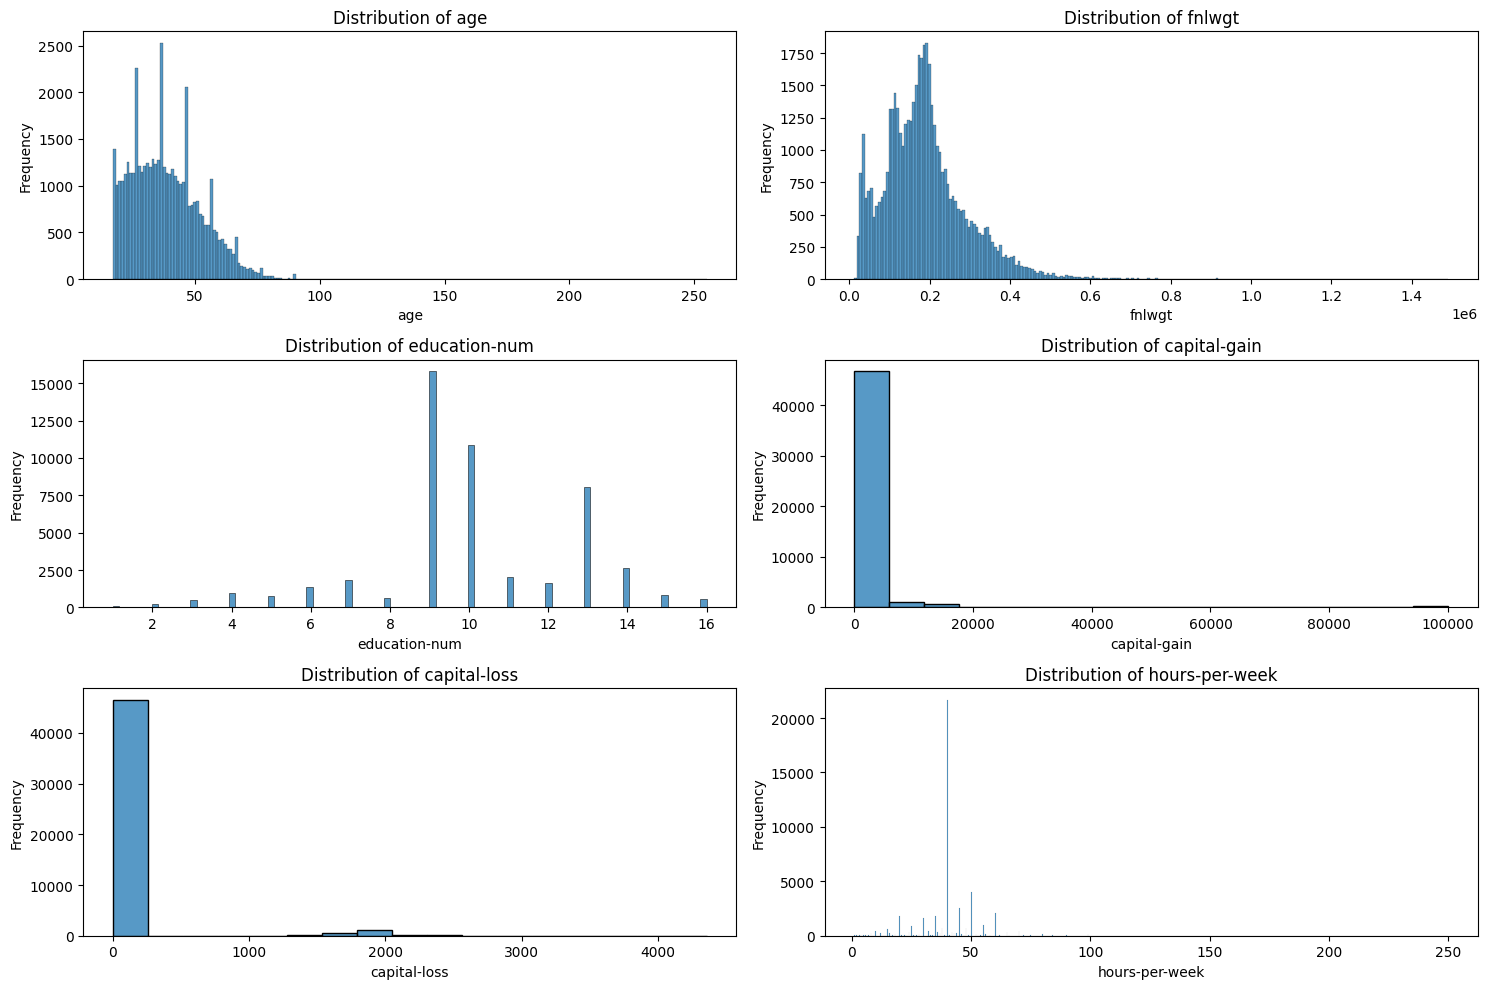

In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i + 1) # Adjust subplot grid as needed
    sns.histplot(df[col].dropna())
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [ ]:
# Fill missing numerical values with the median (recommended for skewed data)
 # add your numeric columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
for col in ['age', 'hours-per-week']:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
# Fill missing categorical values with the mode
cat_cols = df.select_dtypes(include=["object"]).columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
X = df.drop("income", axis=1)

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

cat_cols = X.select_dtypes(include=["object"]).columns

print("Numerical:", list(num_cols))
print("Categorical:", list(cat_cols))

Numerical: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [ ]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

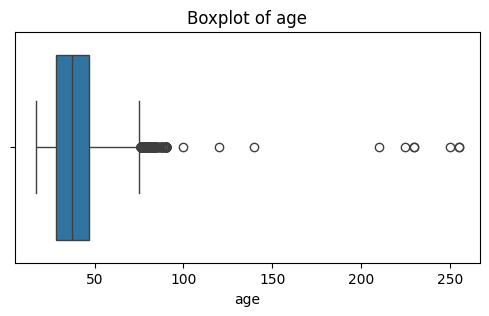

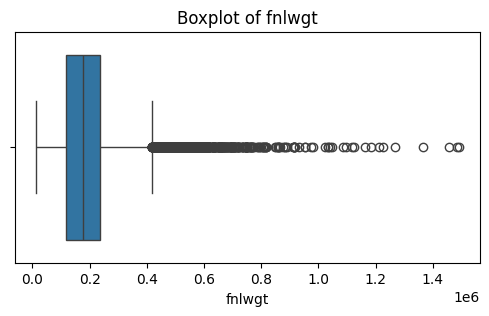

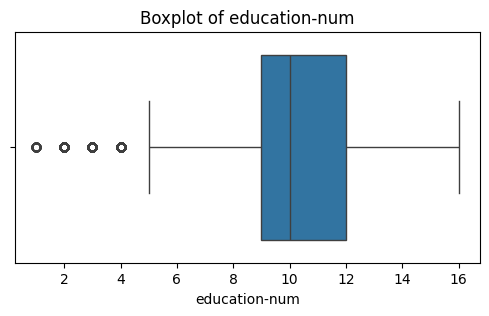

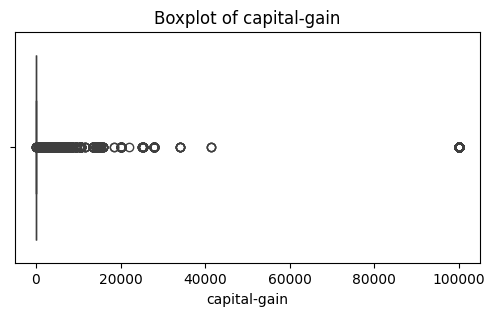

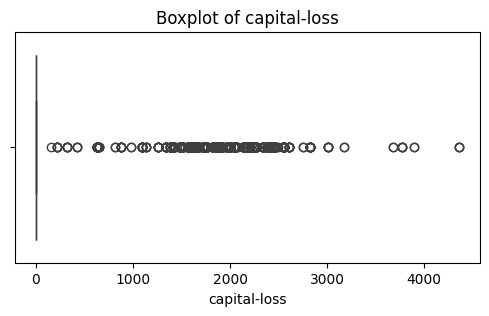

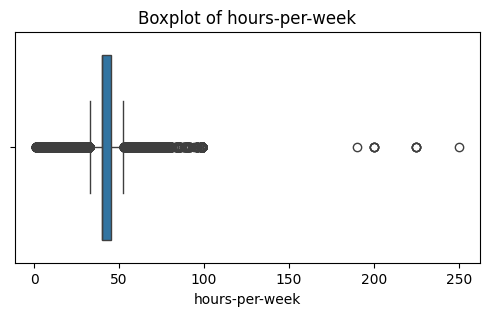

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 3))

    sns.boxplot(x=X[col])

    plt.title(f"Boxplot of {col}")
    plt.show()

In [ ]:
#treating outliers
for col in num_cols:
    Q1 = X[col].quantile(0.25)
    Q3 = X[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = ((X[col] < lower) | (X[col] > upper)).sum()

    print(col, "Outliers:", outliers)

age Outliers: 363
fnlwgt Outliers: 1453
education-num Outliers: 1792
capital-gain Outliers: 4035
capital-loss Outliers: 2282
hours-per-week Outliers: 12833


In [ ]:
# iqr method
X_out = X.copy()

for col in num_cols:
    Q1 = X_out[col].quantile(0.25)
    Q3 = X_out[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    X_out[col] = X_out[col].clip(lower, upper)

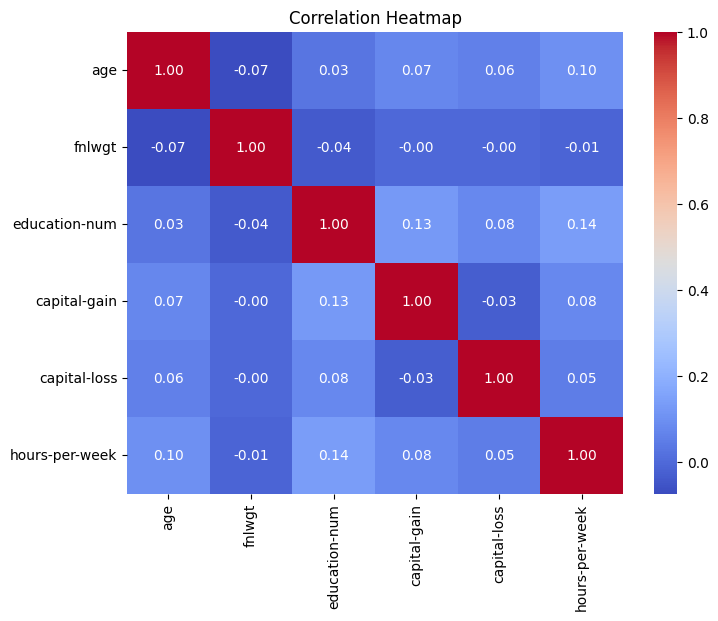

In [ ]:
corr = df[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [ ]:
X_processed = preprocessor.fit_transform(X_out)

print(X_processed.shape)

(48826, 105)


In [ ]:
# dimensionality reduction
pca = PCA(n_components=5)

X_pca = pca.fit_transform(
    X_processed.toarray()
)

print(X_pca.shape)

(48826, 5)


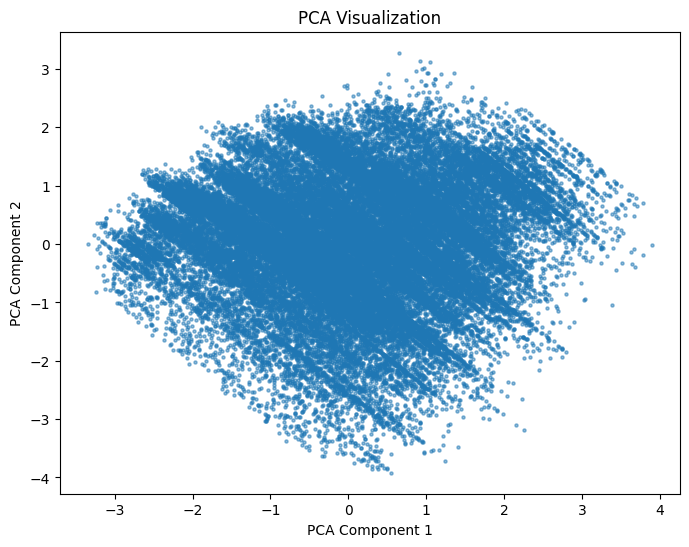

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    s=5,
    alpha=0.5
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization")
plt.show()

In [ ]:
#part 3

In [ ]:
#K-means clustering
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_processed)

    inertia.append(kmeans.inertia_)

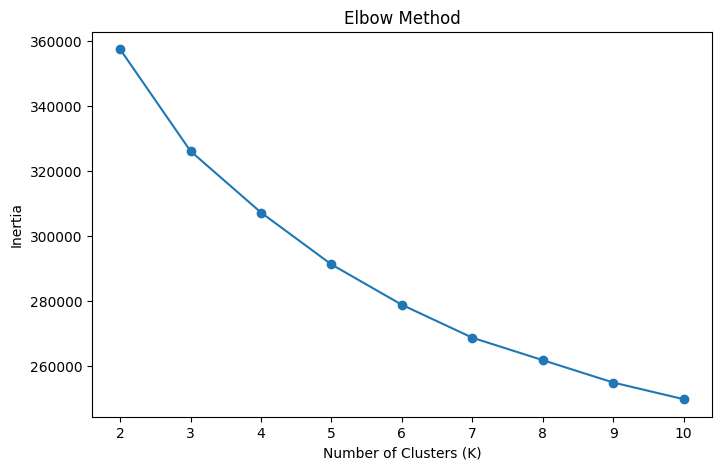

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [ ]:
# train the final kmeans model
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_processed)

df["KMeans_Cluster"] = kmeans_labels

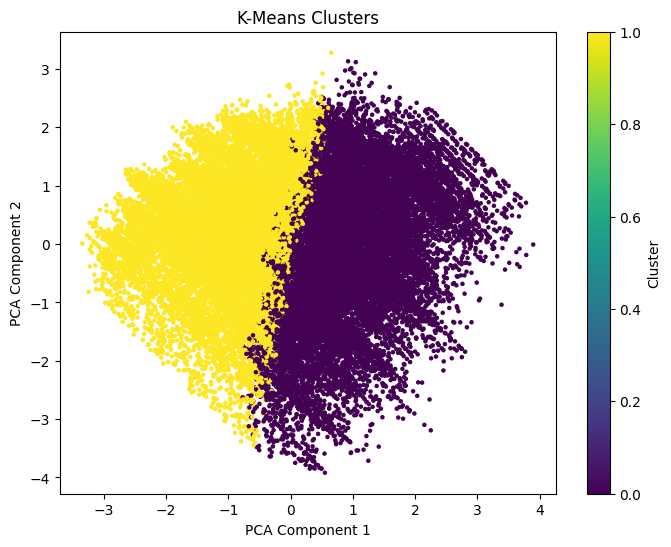

In [ ]:
#visualize kmeans clusters
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap="viridis",
    s=5
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-Means Clusters")

plt.colorbar(label="Cluster")

plt.show()

New Silhouette Score (SVD + K-Means): 0.1596


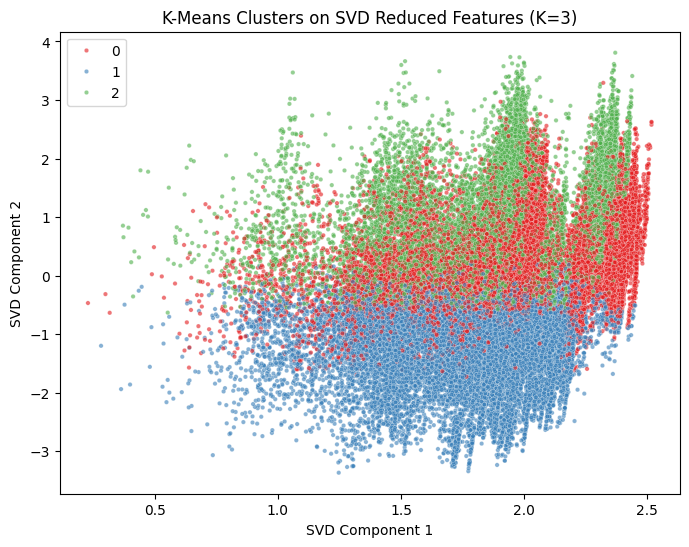

In [ ]:
from sklearn.decomposition import TruncatedSVD

# 1. Reduce high-dimensional space down to 10 dense components using TruncatedSVD
svd = TruncatedSVD(n_components=10, random_state=42)
X_svd = svd.fit_transform(X_processed)

# 2. Fit K-Means on the reduced dense space
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_svd)
df["KMeans_SVD_Cluster"] = cluster_labels

# 3. Calculate Silhouette Score on a sample for speed
score = silhouette_score(X_svd[:5000], cluster_labels[:5000])
print(f"New Silhouette Score (SVD + K-Means): {score:.4f}")

# 4. Visualize cleaner clusters using top 2 SVD components
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_svd[:, 0],
    y=X_svd[:, 1],
    hue=cluster_labels,
    palette='Set1',
    alpha=0.6,
    s=10
)
plt.title('K-Means Clusters on SVD Reduced Features (K=3)')
plt.xlabel('SVD Component 1')
plt.ylabel('SVD Component 2')
plt.show()

In [ ]:
X_sample = X_processed[:2000].toarray()

agg = AgglomerativeClustering(n_clusters=4)

agg_labels = agg.fit_predict(X_sample)

In [ ]:
score = silhouette_score(X_sample, agg_labels)

print("Silhouette Score:", score)

Silhouette Score: 0.07466855178294347


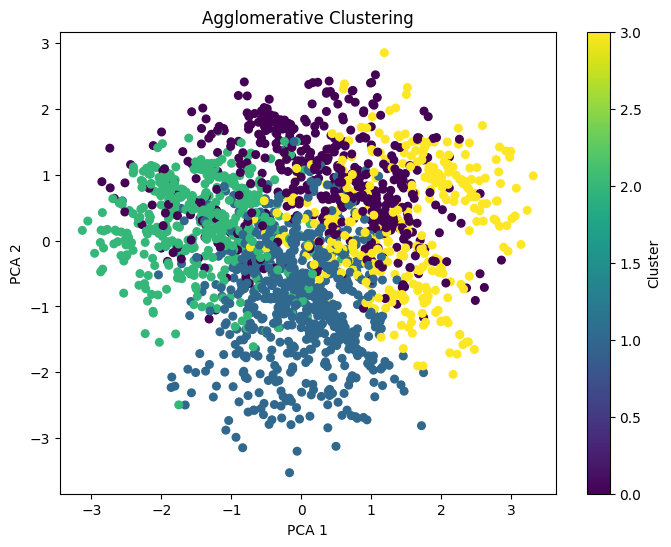

In [ ]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=agg_labels,
    cmap='viridis',
    s=30
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Agglomerative Clustering")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
#4th part

In [ ]:
#cluster profiling and interpretation
df["KMeans_Cluster"].value_counts().sort_index()

,count
KMeans_Cluster,
0,25858
1,22968


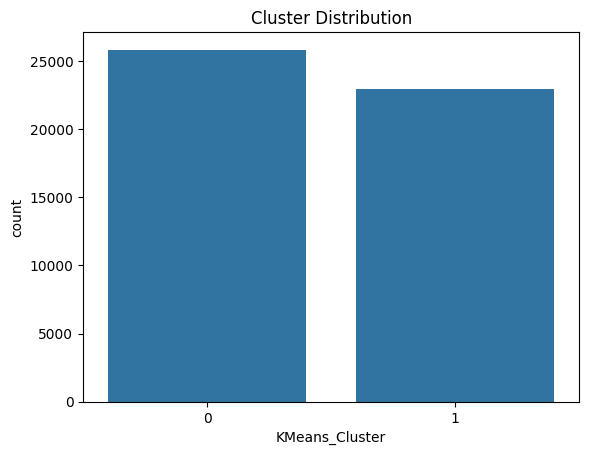

In [ ]:
sns.countplot(
    data=df,
    x="KMeans_Cluster"
)

plt.title("Cluster Distribution")
plt.show()

In [ ]:
profile_num = df.groupby("KMeans_Cluster")[list(num_cols)].mean()

profile_num

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
KMeans_Cluster,,,,,,
0,45.594400,178635.315299,10.602947,1773.209761,119.894617,44.750870
1,30.720045,202072.874739,9.487591,298.335206,51.095132,35.562217


In [ ]:
for col in cat_cols:
    print("\nColumn:", col)

    print(
        df.groupby("KMeans_Cluster")[col]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else "Unknown")
    )


Column: workclass
KMeans_Cluster
0    Private
1    Private
Name: workclass, dtype: object

Column: education
KMeans_Cluster
0    HS-grad
1    HS-grad
Name: education, dtype: object

Column: marital-status
KMeans_Cluster
0    Married-civ-spouse
1         Never-married
Name: marital-status, dtype: object

Column: occupation
KMeans_Cluster
0    Prof-specialty
1    Prof-specialty
Name: occupation, dtype: object

Column: relationship
KMeans_Cluster
0          Husband
1    Not-in-family
Name: relationship, dtype: object

Column: race
KMeans_Cluster
0    White
1    White
Name: race, dtype: object

Column: sex
KMeans_Cluster
0      Male
1    Female
Name: sex, dtype: object

Column: native-country
KMeans_Cluster
0    United-States
1    United-States
Name: native-country, dtype: object


In [ ]:
#comparing with income
pd.crosstab(
    df["KMeans_Cluster"],
    df["income"],
    normalize="index"
) * 100

income,<=50K,<=50K.,>50K,>50K.
KMeans_Cluster,,,,
0,39.206435,20.051821,27.295228,13.446516
1,63.440439,31.543887,3.409091,1.606583


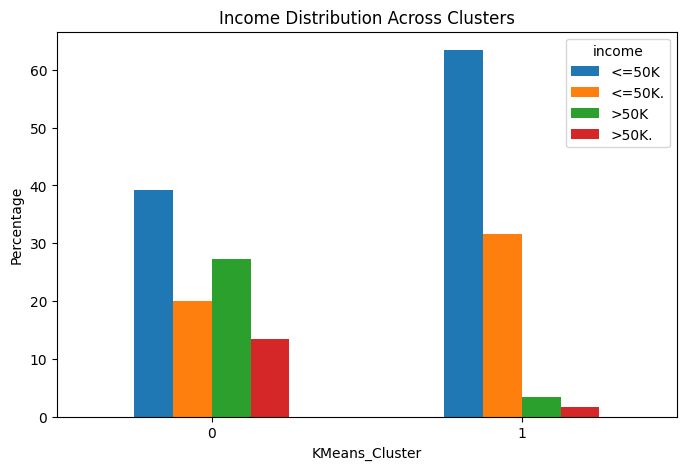

In [ ]:
income_table = pd.crosstab(
    df["KMeans_Cluster"],
    df["income"],
    normalize="index"
) * 100

income_table.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.ylabel("Percentage")
plt.title("Income Distribution Across Clusters")

plt.xticks(rotation=0)
plt.show()

Policy suggestions should be based on the actual characteristics and needs observed in each cluster.

Observed characteristics



Possible policy consideration




Lower education levels and limited employment opportunities



Accessible upskilling and employment programs




Low working hours and financial vulnerability indicators



Review eligibility for employment support or financial assistance




Limited access to formal financial services



Financial literacy and financial inclusion initiatives




High working hours with limited educational attainment



Flexible skill development programs



Deliverables Checklist
Data loading and missing-value handling,  

Categorical encoding and numerical scaling

Outlier detection using IQR

EDA: distributions and correlation heatmap

PCA visualization

K-Means with elbow method and silhouette score

Agglomerative clustering

Cluster visualization and profiling

Post-hoc income comparison and policy implications